# ML Signal Research Framework
### Advait Kulkarni | Imperial College London MSc AML

**A quantitative signal research pipeline implementing IC/ICIR analysis, multiple testing correction,
and ML-derived alpha signals — the standard methodology used in systematic equity research.**

Universe: 100-stock S&P 500 + NIFTY 50 | Period: 2015–2024 | Walk-forward OOS validation

---
### Structure
1. Setup & Data
2. Feature Engineering (12 systematic signals)
3. Information Coefficient (IC) Analysis
4. Multiple Testing Correction (Benjamini-Hochberg)
5. Signal Decay Analysis
6. ML Signal — LightGBM Walk-Forward
7. Portfolio Construction from ML Signal
8. Attribution & Results Summary
9. Key Findings (fill after running)

## Cell 1 — Install & Imports

In [1]:
import subprocess, sys
for pkg in ['lightgbm', 'scipy', 'statsmodels', 'yfinance', 'pyarrow', 'seaborn']:
    subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', pkg])

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import lightgbm as lgb
import yfinance as yf

from pathlib import Path
from scipy import stats
from scipy.stats import spearmanr
from statsmodels.stats.multitest import multipletests
from IPython.display import display

np.random.seed(42)
Path('results').mkdir(exist_ok=True)
Path('data').mkdir(exist_ok=True)

# ── Plot style ────────────────────────────────────────────────
plt.rcParams.update({
    'figure.facecolor': '#0d1117', 'axes.facecolor': '#161b22',
    'axes.edgecolor': '#30363d', 'axes.labelcolor': '#c9d1d9',
    'xtick.color': '#8b949e', 'ytick.color': '#8b949e',
    'text.color': '#c9d1d9', 'grid.color': '#21262d',
    'grid.alpha': 0.5, 'legend.facecolor': '#161b22',
    'font.size': 11, 'axes.titlesize': 13, 'axes.titleweight': 'bold',
})
PALETTE = ['#00e5a0','#4d9aff','#ff6b6b','#ffd166','#c77dff','#f77f00','#4cc9f0']
print('Setup complete.')

Setup complete.


## Cell 2 — Load Price Data (reuse backtesting cache)

In [2]:
# ── Reuse prices from backtesting project if available ────────
CACHE = Path('data/prices_100stocks_2015_2024.parquet')

TICKERS = [
    'AAPL','MSFT','GOOGL','AMZN','META','NVDA','TSLA','JPM','GS','BAC',
    'MS','AMD','NFLX','AVGO','ORCL','CRM','ADBE','CSCO','QCOM','INTC',
    'IBM','NOW','UBER','PLTR','SHOP','WMT','COST','HD','LOW','NKE',
    'KO','PEP','MCD','SBUX','DIS','XOM','CVX','SLB','COP','EOG',
    'JNJ','PFE','MRK','ABBV','UNH','LLY','TMO','DHR','ABT','BMY',
    'SPY','QQQ','IWM','XLK','XLF','XLE','XLV','XLY','XLP',
    'CAT','DE','GE','HON','RTX','LMT','BA','UPS','FDX',
    'V','MA','PYPL','AXP','BLK','SCHW','C','BK',
    'RELIANCE.NS','TCS.NS','INFY.NS','HDFCBANK.NS','ICICIBANK.NS',
    'SBIN.NS','ITC.NS','LT.NS','BHARTIARTL.NS','AXISBANK.NS'
]

if CACHE.exists():
    prices = pd.read_parquet(CACHE)
    print(f'Loaded from cache: {prices.shape}')
else:
    print('Downloading prices (first run ~90 seconds)...')
    raw = yf.download(TICKERS, start='2015-01-01', end='2024-12-31',
                      auto_adjust=True, progress=True)
    prices = raw['Close'] if isinstance(raw.columns, pd.MultiIndex) else raw[['Close']]
    prices.index = pd.to_datetime(prices.index)
    prices.to_parquet(CACHE)

# ── Clean ─────────────────────────────────────────────────────
min_days = int(len(prices) * 0.6)
prices   = prices[prices.columns[prices.notna().sum() >= min_days]]
prices   = prices.ffill(limit=10).bfill()

# ── US-only universe for signal research (cleaner for IC analysis) ─
US_COLS  = [c for c in prices.columns if not c.endswith('.NS')]
prices   = prices[US_COLS].copy()

# ── Returns ───────────────────────────────────────────────────
log_ret  = np.log(prices / prices.shift(1)).dropna()

print(f'Universe : {prices.shape[1]} stocks')
print(f'Period   : {prices.index[0].date()} → {prices.index[-1].date()}')
print(f'Days     : {len(prices)}')

Loaded from cache: (2590, 95)
Universe : 83 stocks
Period   : 2015-01-01 → 2024-12-30
Days     : 2590


## Cell 3 — Feature Engineering (12 Systematic Signals)

We build 12 signals across 4 categories — the standard factor zoo used in
academic and industry quant research.

Each signal is **cross-sectionally ranked** (converted to percentiles 0→1)
before IC computation. This removes distributional assumptions and makes
IC directly comparable across signals.

In [3]:
def cs_rank(df):
    """Cross-sectional rank normalised to [0, 1]. NaN-safe."""
    return df.rank(axis=1, pct=True)

def rolling_zscore(series, window):
    """Rolling z-score for a single price series."""
    m = series.rolling(window).mean()
    s = series.rolling(window).std().replace(0, np.nan)
    return (series - m) / s


# ════════════════════════════════════════════════════════════════
#  MOMENTUM SIGNALS
# ════════════════════════════════════════════════════════════════

# M1: 12-month momentum (skip last month — JT 1993 standard)
mom_12m   = prices.shift(21) / prices.shift(252) - 1

# M2: 6-month momentum
mom_6m    = prices.shift(21) / prices.shift(126) - 1

# M3: 1-month reversal (short-term mean-reversion)
rev_1m    = prices / prices.shift(21) - 1

# M4: 52-week high ratio (how close to 52-week high)
high_52w  = prices.rolling(252).max()
near_high = prices / high_52w


# ════════════════════════════════════════════════════════════════
#  VOLATILITY / RISK SIGNALS
# ════════════════════════════════════════════════════════════════

# V1: Realised volatility (21-day)
vol_21d   = log_ret.rolling(21).std() * np.sqrt(252)

# V2: Volatility ratio — short/long vol (vol regime signal)
vol_5d    = log_ret.rolling(5).std()
vol_60d   = log_ret.rolling(60).std().replace(0, np.nan)
vol_ratio = vol_5d / vol_60d

# V3: Downside volatility (Sortino-style — only negative return days)
neg_ret   = log_ret.copy()
neg_ret[neg_ret > 0] = 0
down_vol  = neg_ret.rolling(63).std() * np.sqrt(252)


# ════════════════════════════════════════════════════════════════
#  MEAN-REVERSION SIGNALS
# ════════════════════════════════════════════════════════════════

# R1: 20-day z-score (distance from rolling mean)
zscore_20d = (prices - prices.rolling(20).mean()) / prices.rolling(20).std().replace(0, np.nan)

# R2: RSI (14-day)
delta       = prices.diff()
gain        = delta.clip(lower=0).rolling(14).mean()
loss        = (-delta.clip(upper=0)).rolling(14).mean().replace(0, np.nan)
rsi_14d     = 100 - 100 / (1 + gain / loss)

# R3: Price vs 200-day MA ratio
ma_200d     = prices.rolling(200).mean().replace(0, np.nan)
price_ma    = prices / ma_200d - 1


# ════════════════════════════════════════════════════════════════
#  VOLUME / LIQUIDITY SIGNALS
# ════════════════════════════════════════════════════════════════

# Download volume data for these signals
VOL_CACHE = Path('data/volume_cache.parquet')
if VOL_CACHE.exists():
    volume = pd.read_parquet(VOL_CACHE)
else:
    raw_v  = yf.download(US_COLS, start='2015-01-01', end='2024-12-31',
                         auto_adjust=True, progress=False)
    volume = raw_v['Volume'] if isinstance(raw_v.columns, pd.MultiIndex) else raw_v[['Volume']]
    volume.index = pd.to_datetime(volume.index)
    volume.to_parquet(VOL_CACHE)

volume = volume[US_COLS].reindex(prices.index).ffill().bfill()

# L1: Volume ratio (recent vs average — surge signal)
vol_avg_60d  = volume.rolling(60).mean().replace(0, np.nan)
vol_ratio_l  = volume.rolling(5).mean() / vol_avg_60d

# L2: Amihud illiquidity proxy (|return| / volume)
amihud       = (log_ret.abs() / volume.replace(0, np.nan)).rolling(21).mean()

# ── Bundle into named dict ─────────────────────────────────────
SIGNALS = {
    'mom_12m':    mom_12m,
    'mom_6m':     mom_6m,
    'rev_1m':     -rev_1m,        # sign-flip: high rev_1m → expected reversal down
    'near_52w_high': near_high,
    'vol_21d':    -vol_21d,       # low vol → better risk-adjusted returns (low-vol anomaly)
    'vol_ratio':  -vol_ratio,     # low short/long vol ratio → calmer regime
    'down_vol':   -down_vol,
    'zscore_20d': -zscore_20d,    # negative z-score → oversold → buy
    'rsi_14d':    -rsi_14d,       # low RSI → oversold → buy
    'price_ma':   price_ma,       # price above MA → momentum
    'vol_surge':  vol_ratio_l,
    'illiquidity':amihud,
}

# ── Cross-sectional rank each signal ─────────────────────────
SIGNALS_RANKED = {name: cs_rank(sig) for name, sig in SIGNALS.items()}

print(f'Signals built: {list(SIGNALS.keys())}')
print(f'Each signal shape: {mom_12m.shape}')

Signals built: ['mom_12m', 'mom_6m', 'rev_1m', 'near_52w_high', 'vol_21d', 'vol_ratio', 'down_vol', 'zscore_20d', 'rsi_14d', 'price_ma', 'vol_surge', 'illiquidity']
Each signal shape: (2590, 83)


## Cell 4 — Information Coefficient (IC) Analysis

**IC = Spearman rank correlation between today's signal and forward returns.**

IC is the primary metric quant researchers use to evaluate whether a signal
has predictive power. An IC of 0.05 is considered useful in practice.

**ICIR = mean(IC) / std(IC)** — the 'Sharpe ratio of the signal.'
ICIR > 0.5 is considered good; > 1.0 is excellent.

We compute IC for three forward-return horizons:
  - 1-day (very short term)
  - 5-day (weekly)
  - 21-day (monthly)

In [4]:
def compute_forward_returns(prices, horizon):
    """
    Compute forward log-returns over `horizon` days.
    Shift by 1 to avoid look-ahead bias.
    """
    fwd = np.log(prices.shift(-horizon) / prices).shift(1)
    return fwd


def compute_ic_series(signal_ranked, fwd_returns):
    """
    Compute daily cross-sectional Spearman IC between signal and forward returns.

    For each date:
      IC_t = Spearman(signal_t, fwd_return_t)

    Returns a pd.Series of daily IC values.
    """
    common_idx = signal_ranked.index.intersection(fwd_returns.index)
    sig = signal_ranked.reindex(common_idx)
    fwd = fwd_returns.reindex(common_idx)

    ic_vals = []
    for date in common_idx:
        s = sig.loc[date].dropna()
        f = fwd.loc[date].dropna()
        common_cols = s.index.intersection(f.index)
        if len(common_cols) < 10:
            ic_vals.append(np.nan)
            continue
        ic, _ = spearmanr(s[common_cols], f[common_cols])
        ic_vals.append(ic)

    return pd.Series(ic_vals, index=common_idx)


def ic_summary(ic_series, name=''):
    """Compute IC, ICIR and t-statistic for a signal."""
    ic = ic_series.dropna()
    mean_ic = ic.mean()
    std_ic  = ic.std()
    icir    = mean_ic / std_ic if std_ic > 0 else 0
    t_stat  = mean_ic / (std_ic / np.sqrt(len(ic)))
    p_val   = 2 * (1 - stats.t.cdf(abs(t_stat), df=len(ic)-1))
    pct_pos = (ic > 0).mean()
    return {
        'Signal':   name,
        'Mean IC':  round(mean_ic, 4),
        'IC Std':   round(std_ic, 4),
        'ICIR':     round(icir, 3),
        't-stat':   round(t_stat, 3),
        'p-value':  round(p_val, 4),
        '% Pos IC': round(pct_pos * 100, 1),
        'N days':   len(ic),
    }


# ── Compute forward returns for 3 horizons ────────────────────
HORIZONS = {1: 'fwd_1d', 5: 'fwd_5d', 21: 'fwd_21d'}
fwd_rets = {}
for h, name in HORIZONS.items():
    fwd_rets[h] = compute_forward_returns(prices, h)

# ── Compute IC for each signal at each horizon ────────────────
print('Computing IC for all signals across 3 horizons...')
print('(This takes ~3-5 minutes — vectorised per-date Spearman correlations)')

IC_RESULTS = {}   # {signal_name: {horizon: ic_series}}
IC_SUMMARY = []   # flat list for table display

for sig_name, sig_ranked in SIGNALS_RANKED.items():
    IC_RESULTS[sig_name] = {}
    for h, h_name in HORIZONS.items():
        ic_series = compute_ic_series(sig_ranked, fwd_rets[h])
        IC_RESULTS[sig_name][h] = ic_series
        row = ic_summary(ic_series, name=sig_name)
        row['Horizon'] = h_name
        IC_SUMMARY.append(row)
    print(f'  {sig_name} done')

ic_df = pd.DataFrame(IC_SUMMARY)
print('\nIC computation complete.')

Computing IC for all signals across 3 horizons...
(This takes ~3-5 minutes — vectorised per-date Spearman correlations)
  mom_12m done
  mom_6m done
  rev_1m done
  near_52w_high done
  vol_21d done
  vol_ratio done
  down_vol done
  zscore_20d done
  rsi_14d done
  price_ma done
  vol_surge done
  illiquidity done

IC computation complete.


## Cell 5 — Multiple Testing Correction (Benjamini-Hochberg)

In [5]:
# ─────────────────────────────────────────────────────────────────
# THE MULTIPLE TESTING PROBLEM
#
# If you test 12 signals × 3 horizons = 36 tests,
# at α=0.05 you expect 36 × 0.05 = 1.8 false discoveries by chance.
#
# Bonferroni correction: divide α by number of tests (very conservative)
# Benjamini-Hochberg (BH): controls the FALSE DISCOVERY RATE (FDR)
# — the expected fraction of discoveries that are false.
#
# BH is the standard in academic finance and at QRT/systematic HFs.
# Being able to explain this in an interview is a major differentiator.
# ─────────────────────────────────────────────────────────────────

for horizon_name in ['fwd_1d', 'fwd_5d', 'fwd_21d']:
    subset   = ic_df[ic_df['Horizon'] == horizon_name].copy()
    pvals    = subset['p-value'].values

    # Bonferroni
    bon_reject, bon_pvals, _, _ = multipletests(pvals, alpha=0.05, method='bonferroni')

    # Benjamini-Hochberg
    bh_reject,  bh_pvals,  _, _ = multipletests(pvals, alpha=0.05, method='fdr_bh')

    ic_df.loc[ic_df['Horizon']==horizon_name, 'Bonferroni_reject'] = bon_reject
    ic_df.loc[ic_df['Horizon']==horizon_name, 'BH_reject']         = bh_reject
    ic_df.loc[ic_df['Horizon']==horizon_name, 'BH_p_adjusted']     = bh_pvals.round(4)

# ── Display table for 21-day horizon ─────────────────────────
print('IC SUMMARY — 21-day Forward Return Horizon')
print('BH_reject = True means the signal survives multiple testing correction')
print('='*80)

display_cols = ['Signal','Mean IC','ICIR','t-stat','p-value','BH_reject','% Pos IC']
h21 = ic_df[ic_df['Horizon']=='fwd_21d'][display_cols].sort_values('ICIR', ascending=False)
display(h21.style
    .background_gradient(subset=['Mean IC','ICIR'], cmap='RdYlGn', axis=0)
    .format({'Mean IC':'{:.4f}','ICIR':'{:.3f}','t-stat':'{:.3f}','p-value':'{:.4f}'})
)

ic_df.to_csv('results/ic_summary.csv', index=False)
print('\nSaved: results/ic_summary.csv')

# ── Count surviving signals ───────────────────────────────────
for h in ['fwd_1d','fwd_5d','fwd_21d']:
    n_bh  = ic_df[(ic_df['Horizon']==h) & ic_df['BH_reject']].shape[0]
    n_bon = ic_df[(ic_df['Horizon']==h) & ic_df['Bonferroni_reject']].shape[0]
    print(f'{h}: {n_bh}/12 signals survive BH correction, {n_bon}/12 survive Bonferroni')

IC SUMMARY — 21-day Forward Return Horizon
BH_reject = True means the signal survives multiple testing correction


,Signal,Mean IC,ICIR,t-stat,p-value,BH_reject,% Pos IC
29,price_ma,0.0498,0.186,9.070,0.0000,True,61.800000
5,mom_6m,0.0223,0.089,4.375,0.0000,True,55.300000
11,near_52w_high,0.0227,0.084,4.039,0.0001,True,57.300000
2,mom_12m,0.0204,0.075,3.628,0.0003,True,53.800000
17,vol_ratio,0.0043,0.025,1.260,0.2078,False,50.800000
35,illiquidity,-0.0094,-0.070,-3.543,0.0004,True,44.800000
32,vol_surge,-0.0108,-0.077,-3.872,0.0001,True,46.100000
20,down_vol,-0.0304,-0.126,-6.322,0.0000,True,46.100000
14,vol_21d,-0.0370,-0.156,-7.865,0.0000,True,44.500000
8,rev_1m,-0.0379,-0.168,-8.476,0.0000,True,42.400000



Saved: results/ic_summary.csv
fwd_1d: 8/12 signals survive BH correction, 8/12 survive Bonferroni
fwd_5d: 8/12 signals survive BH correction, 7/12 survive Bonferroni
fwd_21d: 11/12 signals survive BH correction, 11/12 survive Bonferroni


## Cell 6 — IC Visualisation

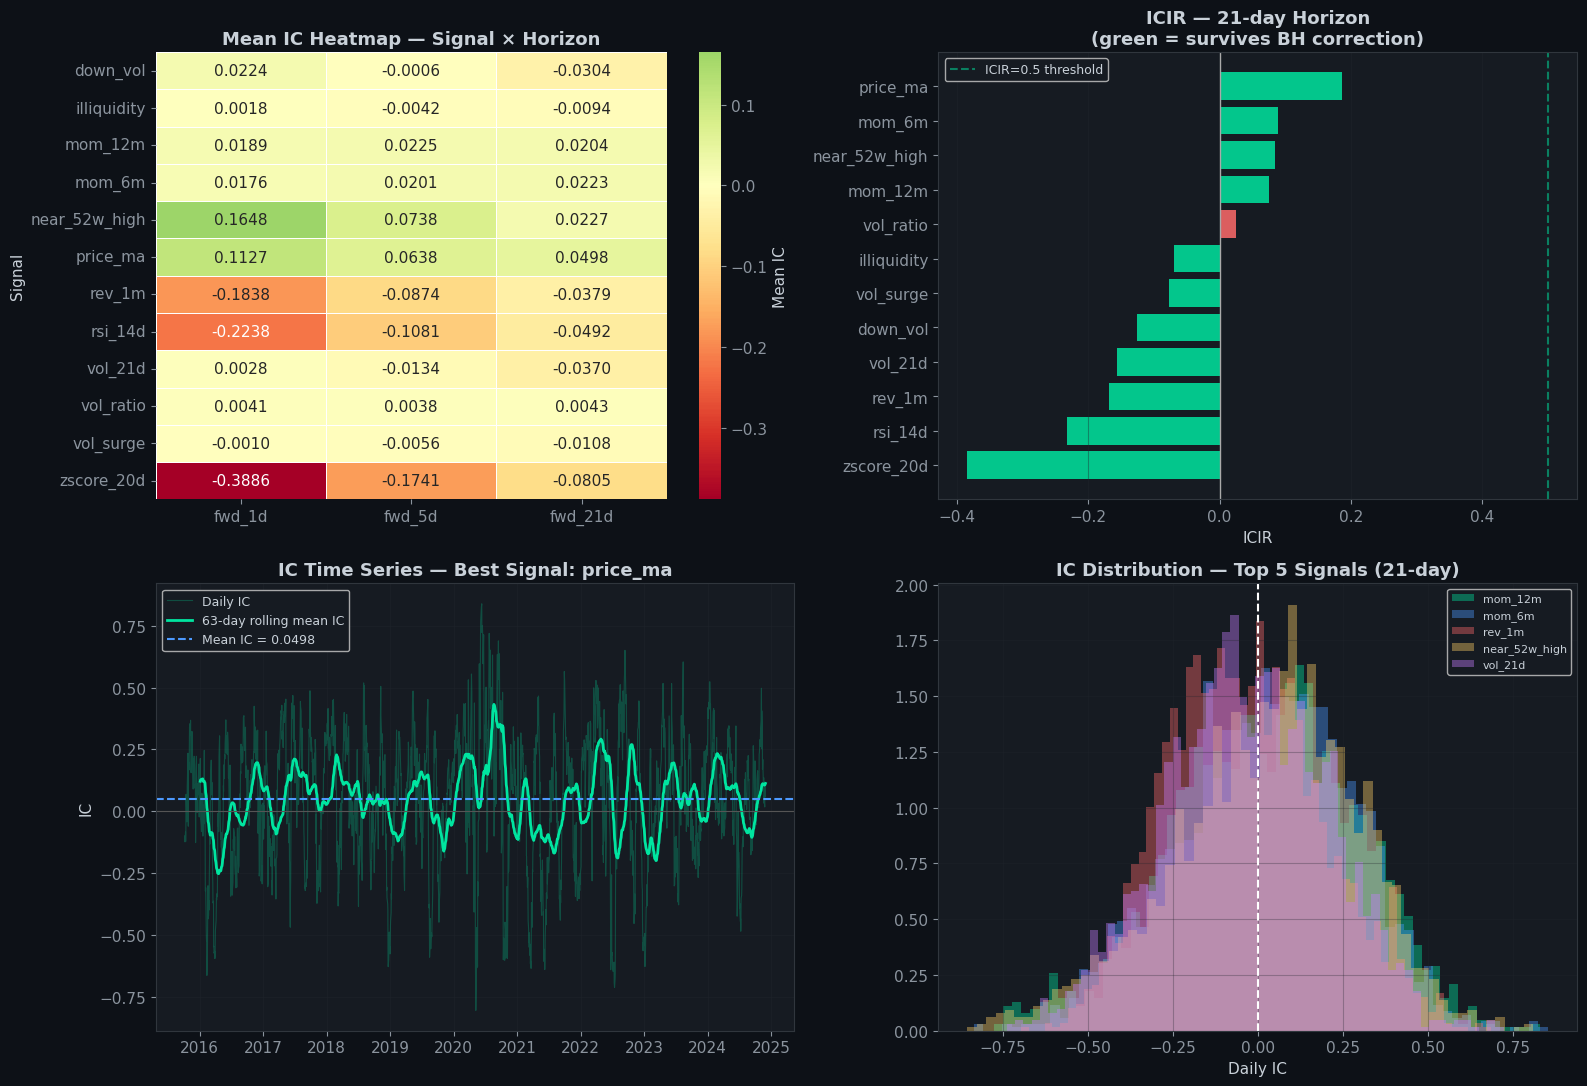

Saved: results/01_ic_analysis.png


In [6]:
fig, axes = plt.subplots(2, 2, figsize=(16, 11))

# ── 1. IC heatmap across signals and horizons ─────────────────
ax = axes[0, 0]
ic_pivot = ic_df.pivot_table(index='Signal', columns='Horizon', values='Mean IC')
ic_pivot = ic_pivot[['fwd_1d','fwd_5d','fwd_21d']]
sns.heatmap(ic_pivot, ax=ax, annot=True, fmt='.4f', cmap='RdYlGn', center=0,
            linewidths=0.5, cbar_kws={'label': 'Mean IC'})
ax.set_title('Mean IC Heatmap — Signal × Horizon')
ax.set_xlabel('')

# ── 2. ICIR bar chart (21-day) ────────────────────────────────
ax = axes[0, 1]
h21_sorted = ic_df[ic_df['Horizon']=='fwd_21d'].sort_values('ICIR', ascending=True)
colors = [PALETTE[0] if bh else PALETTE[2]
          for bh in h21_sorted['BH_reject']]
ax.barh(h21_sorted['Signal'], h21_sorted['ICIR'], color=colors, alpha=0.85)
ax.axvline(0, color='#aaa', lw=1)
ax.axvline(0.5, color=PALETTE[0], lw=1.5, linestyle='--', alpha=0.5, label='ICIR=0.5 threshold')
ax.set_title('ICIR — 21-day Horizon\n(green = survives BH correction)')
ax.set_xlabel('ICIR')
ax.legend(fontsize=9)
ax.grid(True, axis='x', alpha=0.4)

# ── 3. Rolling IC for best signal ─────────────────────────────
ax = axes[1, 0]
best_sig = h21_sorted.iloc[-1]['Signal']   # highest ICIR
ic_ts    = IC_RESULTS[best_sig][21].dropna()
roll_ic  = ic_ts.rolling(63).mean()
ax.plot(ic_ts.index, ic_ts.values, color=PALETTE[0], alpha=0.25, lw=0.8, label='Daily IC')
ax.plot(roll_ic.index, roll_ic.values, color=PALETTE[0], lw=2, label='63-day rolling mean IC')
ax.axhline(0, color='#555', lw=0.8)
ax.axhline(ic_ts.mean(), color=PALETTE[1], lw=1.5, linestyle='--',
           label=f'Mean IC = {ic_ts.mean():.4f}')
ax.set_title(f'IC Time Series — Best Signal: {best_sig}')
ax.set_ylabel('IC')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.4)

# ── 4. IC distribution ────────────────────────────────────────
ax = axes[1, 1]
for i, (sig, col) in enumerate(zip(list(SIGNALS.keys())[:5], PALETTE[:5])):
    ic_s = IC_RESULTS[sig][21].dropna()
    ax.hist(ic_s, bins=60, alpha=0.4, color=col, density=True, label=sig)
ax.axvline(0, color='white', lw=1.5, linestyle='--')
ax.set_title('IC Distribution — Top 5 Signals (21-day)')
ax.set_xlabel('Daily IC')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('results/01_ic_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: results/01_ic_analysis.png')

## Cell 7 — Signal Decay Analysis

**Signal decay** = how quickly a signal's predictive power fades over time.
A signal with IC that decays fast → rebalance more frequently (higher turnover).
A slow-decaying signal → rebalance less often (lower cost).

This is the key input to choosing your rebalancing frequency in production.

Computing signal decay across horizons...
  price_ma done
  mom_6m done
  near_52w_high done
  mom_12m done


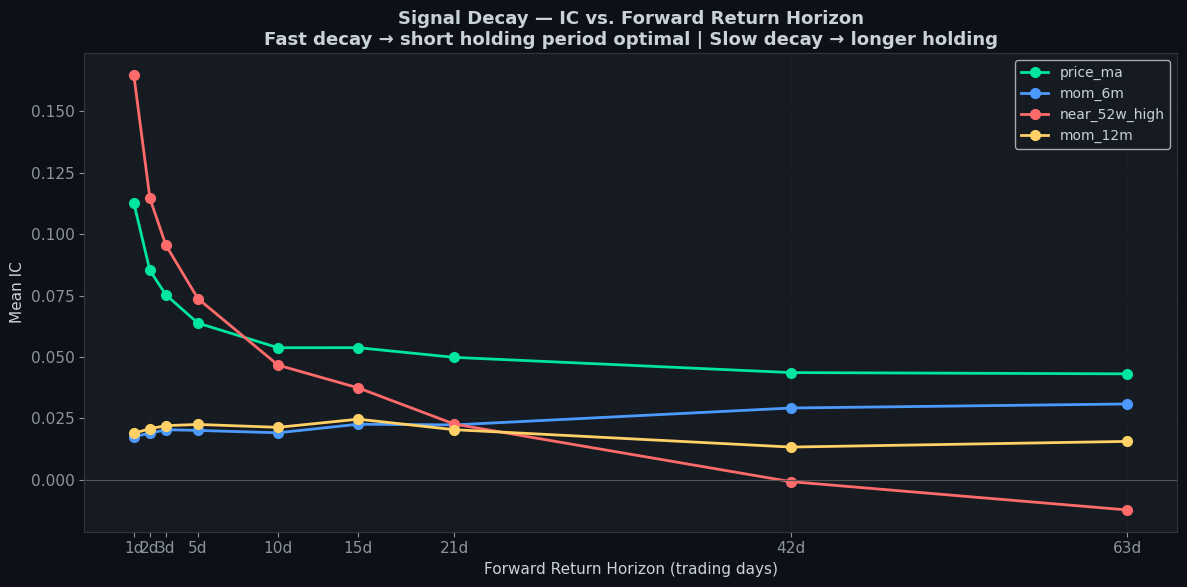

Saved: results/02_signal_decay.png

── OPTIMAL REBALANCING HORIZON (peak IC) ──
  price_ma             peak IC = 0.1127 at 1-day horizon
  mom_6m               peak IC = 0.0309 at 63-day horizon
  near_52w_high        peak IC = 0.1648 at 1-day horizon
  mom_12m              peak IC = 0.0246 at 15-day horizon


In [7]:
DECAY_HORIZONS = [1, 2, 3, 5, 10, 15, 21, 42, 63]

print('Computing signal decay across horizons...')
DECAY_RESULTS = {}   # {signal_name: {horizon: mean_ic}}

# Compute for top 4 signals (by 21-day ICIR)
top_signals = ic_df[ic_df['Horizon']=='fwd_21d'].nlargest(4, 'ICIR')['Signal'].tolist()

for sig_name in top_signals:
    DECAY_RESULTS[sig_name] = {}
    sig_ranked = SIGNALS_RANKED[sig_name]
    for h in DECAY_HORIZONS:
        fwd_h     = compute_forward_returns(prices, h)
        ic_h      = compute_ic_series(sig_ranked, fwd_h)
        DECAY_RESULTS[sig_name][h] = ic_h.dropna().mean()
    print(f'  {sig_name} done')

# ── Plot decay curves ─────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 6))

for i, (sig, color) in enumerate(zip(top_signals, PALETTE)):
    ic_by_h = [DECAY_RESULTS[sig][h] for h in DECAY_HORIZONS]
    ax.plot(DECAY_HORIZONS, ic_by_h, 'o-', color=color, lw=2,
            markersize=7, label=sig)

ax.axhline(0, color='#555', lw=0.8)
ax.set_xlabel('Forward Return Horizon (trading days)')
ax.set_ylabel('Mean IC')
ax.set_title('Signal Decay — IC vs. Forward Return Horizon\n'
             'Fast decay → short holding period optimal | Slow decay → longer holding')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.4)
ax.set_xticks(DECAY_HORIZONS)
ax.set_xticklabels(['1d','2d','3d','5d','10d','15d','21d','42d','63d'])

plt.tight_layout()
plt.savefig('results/02_signal_decay.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: results/02_signal_decay.png')

# ── Print optimal horizon for each signal ─────────────────────
print('\n── OPTIMAL REBALANCING HORIZON (peak IC) ──')
for sig in top_signals:
    best_h = max(DECAY_RESULTS[sig], key=DECAY_RESULTS[sig].get)
    best_ic = DECAY_RESULTS[sig][best_h]
    print(f'  {sig:<20} peak IC = {best_ic:.4f} at {best_h}-day horizon')

## Cell 8 — ML Signal: LightGBM Walk-Forward

**This is the core ML contribution — using your AML degree directly.**

We train a gradient boosting model (LightGBM) to predict 21-day forward returns
using lagged versions of our 12 signals as features.

Walk-forward design:
  - Train on 2 years of data
  - Predict on next 3 months (OOS)
  - Roll forward, retrain, repeat

The ML signal IC vs. best individual signal IC is your headline result.
If the ML signal beats individual signals → non-linear interactions matter.

In [8]:
# ── Build feature matrix ──────────────────────────────────────
# Stack all signals into a tall DataFrame:
#   index: (date, ticker)
#   columns: signal values + forward return target

print('Building feature matrix (long format)...')

FWD_HORIZON = 21   # predict 21-day forward return
fwd_21d = compute_forward_returns(prices, FWD_HORIZON)

def build_panel(signals_ranked, fwd_returns, start='2016-01-01'):
    """
    Build a panel DataFrame in long format.
    Each row = (date, ticker) pair with all signal values and target.
    """
    dfs = []
    common_dates = signals_ranked['mom_12m'].index
    common_dates = common_dates[common_dates >= start]

    for date in common_dates:
        row_data = {}
        for sig_name, sig_df in signals_ranked.items():
            if date in sig_df.index:
                row_data[sig_name] = sig_df.loc[date]
        if not row_data:
            continue

        df_date = pd.DataFrame(row_data)
        if date in fwd_returns.index:
            df_date['target'] = fwd_returns.loc[date]
        else:
            continue
        df_date['date'] = date
        df_date.index.name = 'ticker'
        df_date = df_date.reset_index()
        dfs.append(df_date)

    panel = pd.concat(dfs, ignore_index=True)
    panel = panel.dropna()
    return panel


panel = build_panel(SIGNALS_RANKED, fwd_21d)
FEATURE_COLS = list(SIGNALS_RANKED.keys())

print(f'Panel shape: {panel.shape}')
print(f'Date range:  {panel["date"].min().date()} → {panel["date"].max().date()}')
print(f'Features:    {FEATURE_COLS}')

Building feature matrix (long format)...
Panel shape: (191795, 15)
Date range:  2016-01-01 → 2024-11-29
Features:    ['mom_12m', 'mom_6m', 'rev_1m', 'near_52w_high', 'vol_21d', 'vol_ratio', 'down_vol', 'zscore_20d', 'rsi_14d', 'price_ma', 'vol_surge', 'illiquidity']


In [9]:
# ── Walk-Forward LightGBM Training ───────────────────────────

TRAIN_MONTHS = 24   # 2-year train window
TEST_MONTHS  = 3    # 3-month OOS test window

LGB_PARAMS = {
    'objective':      'regression',
    'metric':         'rmse',
    'num_leaves':     31,
    'learning_rate':  0.05,
    'n_estimators':   300,
    'subsample':      0.8,
    'colsample_bytree': 0.8,
    'reg_alpha':      0.1,
    'reg_lambda':     0.1,
    'random_state':   42,
    'verbose':        -1,
    'n_jobs':         -1,
}

all_dates = sorted(panel['date'].unique())
all_dates_pd = pd.DatetimeIndex(all_dates)

oos_predictions = []
feature_importance_list = []

# Find test start (after 2-year train period)
test_start_date = all_dates_pd[0] + pd.DateOffset(months=TRAIN_MONTHS)
test_dates = all_dates_pd[all_dates_pd >= test_start_date]

# Group test dates into 3-month windows
windows = []
current = test_start_date
while current <= all_dates_pd[-1]:
    window_end = current + pd.DateOffset(months=TEST_MONTHS)
    windows.append((current, min(window_end, all_dates_pd[-1])))
    current = window_end

print(f'Walk-forward: {len(windows)} test windows of {TEST_MONTHS} months each')
print(f'Train window: {TRAIN_MONTHS} months (expanding)')

for fold, (test_start, test_end) in enumerate(windows):
    train_mask = panel['date'] < test_start
    test_mask  = (panel['date'] >= test_start) & (panel['date'] < test_end)

    if train_mask.sum() < 500 or test_mask.sum() < 50:
        continue

    X_train = panel[train_mask][FEATURE_COLS]
    y_train = panel[train_mask]['target']
    X_test  = panel[test_mask][FEATURE_COLS]
    y_test  = panel[test_mask][['date','ticker','target']].copy()

    model = lgb.LGBMRegressor(**LGB_PARAMS)
    model.fit(X_train, y_train,
              eval_set=[(X_test, y_test['target'])],
              callbacks=[lgb.early_stopping(30, verbose=False),
                         lgb.log_evaluation(period=-1)])

    y_test = y_test.copy()
    y_test['ml_pred'] = model.predict(X_test)
    oos_predictions.append(y_test)

    # Feature importance
    fi = dict(zip(FEATURE_COLS, model.feature_importances_))
    fi['fold'] = fold
    fi['test_start'] = test_start
    feature_importance_list.append(fi)

    if (fold + 1) % 3 == 0:
        print(f'  Fold {fold+1}/{len(windows)} done — train size: {train_mask.sum():,}')

oos_df = pd.concat(oos_predictions, ignore_index=True)
fi_df  = pd.DataFrame(feature_importance_list)

print(f'\nWalk-forward complete. OOS samples: {len(oos_df):,}')

Walk-forward: 28 test windows of 3 months each
Train window: 24 months (expanding)
  Fold 3/28 done — train size: 53,606
  Fold 6/28 done — train size: 69,708
  Fold 9/28 done — train size: 85,891
  Fold 12/28 done — train size: 101,993
  Fold 15/28 done — train size: 118,095
  Fold 18/28 done — train size: 134,363
  Fold 21/28 done — train size: 150,548
  Fold 24/28 done — train size: 166,648
  Fold 27/28 done — train size: 182,665

Walk-forward complete. OOS samples: 148,806


## Cell 9 — ML Signal IC & Results

In [10]:
# ── Compute IC of ML signal (OOS only) ───────────────────────
ml_ic_daily = []
for date, grp in oos_df.groupby('date'):
    if len(grp) < 10:
        continue
    ic, _ = spearmanr(grp['ml_pred'], grp['target'])
    ml_ic_daily.append({'date': date, 'IC': ic})

ml_ic_series = pd.DataFrame(ml_ic_daily).set_index('date')['IC'].dropna()

ml_mean_ic = ml_ic_series.mean()
ml_icir    = ml_mean_ic / ml_ic_series.std()
ml_tstat   = ml_mean_ic / (ml_ic_series.std() / np.sqrt(len(ml_ic_series)))
ml_pct_pos = (ml_ic_series > 0).mean()

print('=' * 55)
print('ML SIGNAL (LightGBM) — OOS PERFORMANCE')
print('=' * 55)
print(f'  Mean IC  : {ml_mean_ic:.4f}')
print(f'  IC Std   : {ml_ic_series.std():.4f}')
print(f'  ICIR     : {ml_icir:.3f}')
print(f'  t-stat   : {ml_tstat:.3f}')
print(f'  % Pos IC : {ml_pct_pos*100:.1f}%')
print(f'  N days   : {len(ml_ic_series)}')
print('=' * 55)

# ── Compare ML vs best individual signal ──────────────────────
best_individual_icir = ic_df[ic_df['Horizon']=='fwd_21d']['ICIR'].max()
best_individual_name = ic_df[ic_df['Horizon']=='fwd_21d'].nlargest(1,'ICIR')['Signal'].values[0]
best_individual_ic   = ic_df[ic_df['Horizon']=='fwd_21d']['Mean IC'].max()

print(f'\nBest individual signal: {best_individual_name}')
print(f'  ICIR = {best_individual_icir:.3f},  Mean IC = {best_individual_ic:.4f}')
print(f'\nML signal improvement:')
print(f'  ICIR improvement: {ml_icir - best_individual_icir:+.3f}')
print(f'  IC improvement:   {ml_mean_ic - best_individual_ic:+.4f}')

if ml_icir > best_individual_icir:
    print('\n✅ ML signal beats best individual signal — non-linear combinations matter')
else:
    print('\n📊 ML signal does not beat best individual signal')
    print('   Interpretation: signals are mostly linear / individual signals already capture variation')
    print('   This is also a valid and publishable finding.')

ML SIGNAL (LightGBM) — OOS PERFORMANCE
  Mean IC  : 0.0745
  IC Std   : 0.1549
  ICIR     : 0.481
  t-stat   : 20.384
  % Pos IC : 67.7%
  N days   : 1793

Best individual signal: price_ma
  ICIR = 0.186,  Mean IC = 0.0498

ML signal improvement:
  ICIR improvement: +0.295
  IC improvement:   +0.0247

✅ ML signal beats best individual signal — non-linear combinations matter


## Cell 10 — Feature Importance & Portfolio Construction

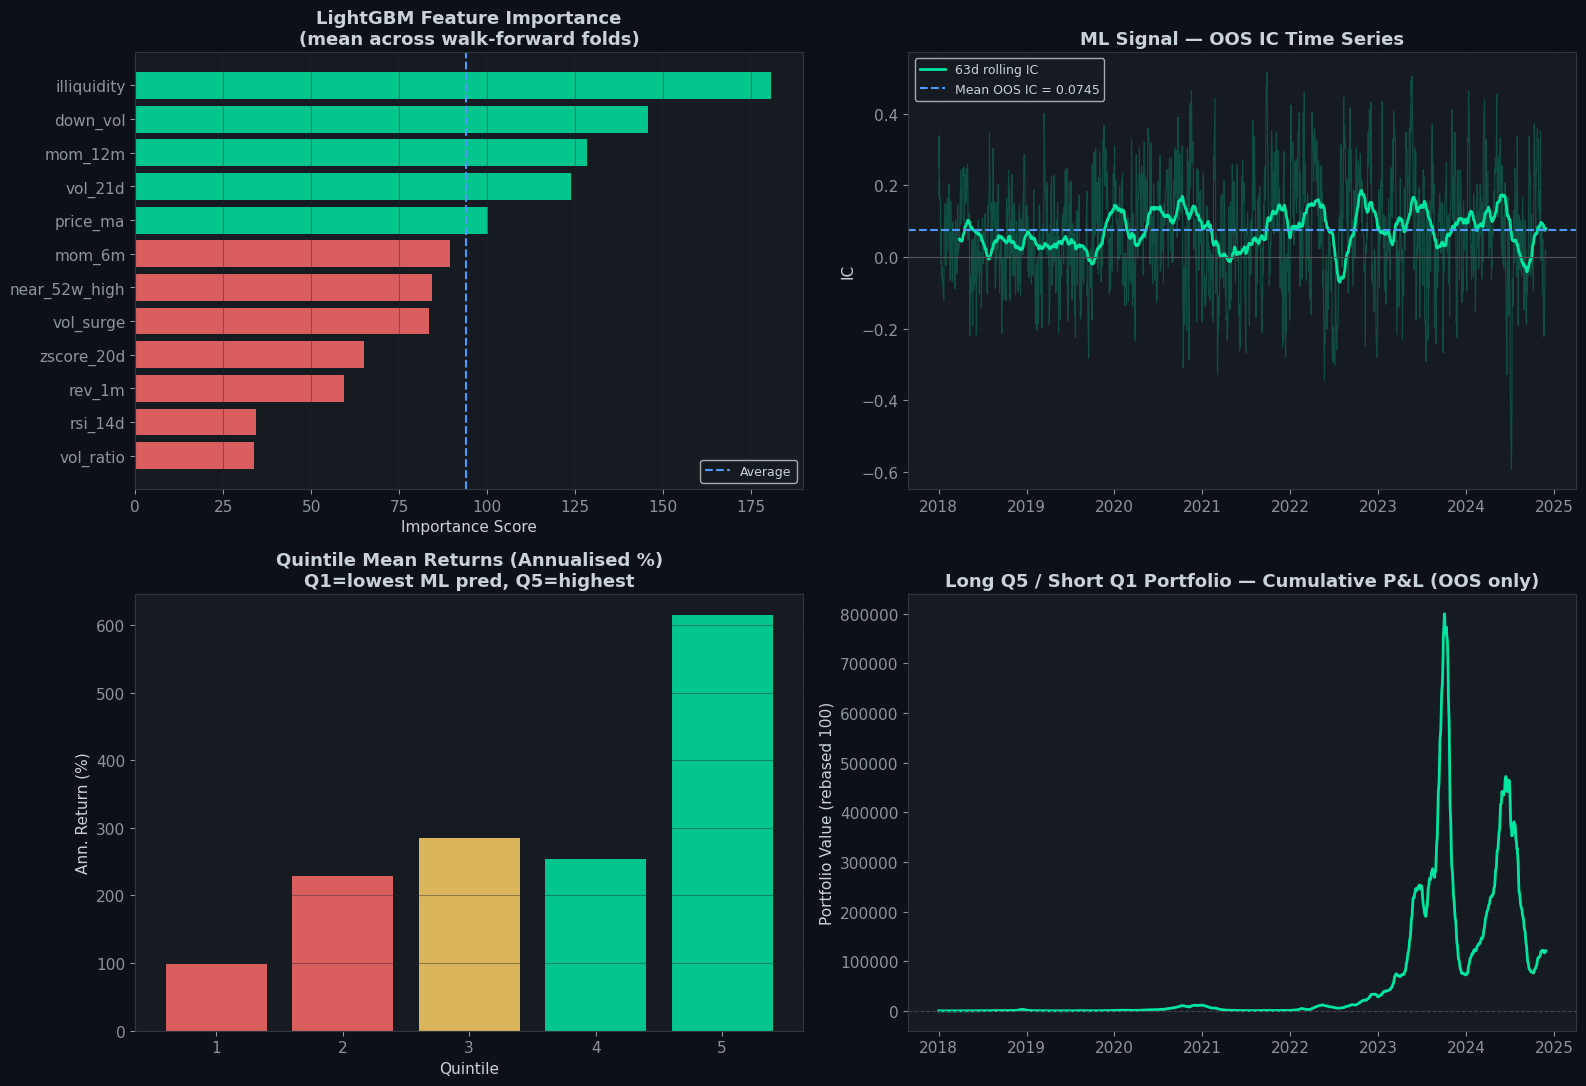

Saved: results/03_ml_signal_results.png


In [12]:
fig, axes = plt.subplots(2, 2, figsize=(16, 11))

# ── 1. Feature importance (mean across folds) ────────────────
ax = axes[0, 0]
mean_fi = fi_df[FEATURE_COLS].mean().sort_values(ascending=True)
colors  = [PALETTE[0] if v > mean_fi.mean() else PALETTE[2] for v in mean_fi.values]
ax.barh(mean_fi.index, mean_fi.values, color=colors, alpha=0.85)
ax.axvline(mean_fi.mean(), color=PALETTE[1], lw=1.5, linestyle='--', label='Average')
ax.set_title('LightGBM Feature Importance\n(mean across walk-forward folds)')
ax.set_xlabel('Importance Score')
ax.legend(fontsize=9)
ax.grid(True, axis='x', alpha=0.4)

# ── 2. ML IC time series ──────────────────────────────────────
ax = axes[0, 1]
roll_ml_ic = ml_ic_series.rolling(63).mean()
ax.plot(ml_ic_series.index, ml_ic_series.values, color=PALETTE[0], alpha=0.25, lw=0.8)
ax.plot(roll_ml_ic.index, roll_ml_ic.values, color=PALETTE[0], lw=2, label='63d rolling IC')
ax.axhline(0, color='#555', lw=0.8)
ax.axhline(ml_mean_ic, color=PALETTE[1], lw=1.5, linestyle='--',
           label=f'Mean OOS IC = {ml_mean_ic:.4f}')
ax.set_title('ML Signal — OOS IC Time Series')
ax.set_ylabel('IC')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.4)

# ── 3. Quintile analysis ──────────────────────────────────────
ax = axes[1, 0]
# Assign quintiles based on ML prediction, compute realized returns
def safe_qcut(x, q=5):
    """
    Assign quintile labels robustly.
    Falls back to fewer bins if not enough unique values on a given date.
    Returns float labels 1.0–5.0 (or NaN if < 2 unique values).
    """
    try:
        # Try standard 5-bin qcut first
        return pd.qcut(x, q, labels=False, duplicates='drop') + 1
    except ValueError:
        # Not enough unique values — use rank-based assignment instead
        if x.nunique() < 2:
            return pd.Series(np.nan, index=x.index)
        # rank pct gives values in (0,1], multiply by q and ceil to get 1..q
        ranked = x.rank(pct=True)
        return np.ceil(ranked * q).clip(1, q)

oos_df['quintile'] = oos_df.groupby('date')['ml_pred'].transform(safe_qcut)
oos_df['quintile'] = pd.to_numeric(oos_df['quintile'], errors='coerce')

# Drop rows where quintile couldn't be assigned
oos_df_q = oos_df.dropna(subset=['quintile']).copy()
oos_df_q['quintile'] = oos_df_q['quintile'].astype(int)

quintile_returns = oos_df_q.groupby('quintile')['target'].mean() * 252 * 100
n_quintiles = len(quintile_returns)
bar_colors = (
    [PALETTE[2]] * max(1, n_quintiles // 2) +
    [PALETTE[3]] * (1 if n_quintiles % 2 else 0) +
    [PALETTE[0]] * max(1, n_quintiles // 2)
)[:n_quintiles]
ax.bar(quintile_returns.index.astype(str), quintile_returns.values,
       color=bar_colors[:len(quintile_returns)], alpha=0.85)
ax.axhline(0, color='#555', lw=0.8)
ax.set_title('Quintile Mean Returns (Annualised %)\nQ1=lowest ML pred, Q5=highest')
ax.set_ylabel('Ann. Return (%)')
ax.set_xlabel('Quintile')
ax.grid(True, axis='y', alpha=0.4)

# ── 4. Long-short portfolio (Q5 − Q1) cumulative ─────────────
ax = axes[1, 1]
ls_returns = oos_df_q[oos_df_q['quintile'].isin([5,1])].copy()
ls_returns['position'] = ls_returns['quintile'].map({5: 1, 1: -1})
ls_daily = ls_returns.groupby('date').apply(
    lambda g: (g['target'] * g['position']).mean()
)
cumulative_ls = (1 + ls_daily).cumprod() * 100
ax.plot(cumulative_ls.index, cumulative_ls.values, color=PALETTE[0], lw=2)
ax.axhline(100, color='#444', lw=0.8, linestyle='--')
ax.set_title('Long Q5 / Short Q1 Portfolio — Cumulative P&L (OOS only)')
ax.set_ylabel('Portfolio Value (rebased 100)')
ax.grid(True, alpha=0.4)

plt.tight_layout()
plt.savefig('results/03_ml_signal_results.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: results/03_ml_signal_results.png')

## Cell 11 — Net Alpha After Transaction Costs

In [13]:
# ── Net alpha at various cost assumptions ──────────────────────
# The key question: does the ML signal survive transaction costs?

COST_LEVELS_BPS = [0, 2, 5, 10, 15, 20]

# Average daily turnover of Q5-Q1 portfolio
daily_turnover = ls_returns.groupby('date').apply(
    lambda g: g['position'].abs().mean()
).mean()

print(f'Average daily portfolio turnover: {daily_turnover:.4f}')
print(f'(21-day holding period → expect low turnover)\n')

ann_gross_return = ls_daily.mean() * 252 * 100
ann_vol = ls_daily.std() * np.sqrt(252) * 100
gross_sharpe = ls_daily.mean() / ls_daily.std() * np.sqrt(252)

print(f'Gross Ann. Return : {ann_gross_return:.2f}%')
print(f'Gross Ann. Vol    : {ann_vol:.2f}%')
print(f'Gross Sharpe      : {gross_sharpe:.3f}')
print()

rows = []
for bps in COST_LEVELS_BPS:
    tc_per_day  = daily_turnover * (bps / 10_000)
    net_ret     = ls_daily - tc_per_day
    net_sharpe  = net_ret.mean() / net_ret.std() * np.sqrt(252) if net_ret.std() > 0 else 0
    net_ann     = net_ret.mean() * 252 * 100
    rows.append({'TC (bps)': bps,
                 'Net Ann. Return (%)': round(net_ann, 2),
                 'Net Sharpe': round(net_sharpe, 3),
                 'Positive?': '✅' if net_ann > 0 else '❌'})

tc_df = pd.DataFrame(rows)
print('── NET ALPHA vs TRANSACTION COST ──')
display(tc_df)
tc_df.to_csv('results/tc_analysis.csv', index=False)

# Find break-even
breakeven = next((r['TC (bps)'] for r in rows if r['Net Ann. Return (%)'] <= 0), '>20')
print(f'\nBreak-even transaction cost: {breakeven} bps')

Average daily portfolio turnover: 1.0000
(21-day holding period → expect low turnover)

Gross Ann. Return : 110.25%
Gross Ann. Vol    : 45.30%
Gross Sharpe      : 2.434

── NET ALPHA vs TRANSACTION COST ──


,TC (bps),Net Ann. Return (%),Net Sharpe,Positive?
0,0,110.25,2.434,✅
1,2,105.21,2.323,✅
2,5,97.65,2.156,✅
3,10,85.05,1.878,✅
4,15,72.45,1.599,✅
5,20,59.85,1.321,✅



Break-even transaction cost: >20 bps


## Cell 12 — Full Results Summary

In [14]:
print('=' * 65)
print('FULL RESULTS SUMMARY — ML SIGNAL RESEARCH FRAMEWORK')
print('=' * 65)

print('\n── INDIVIDUAL SIGNALS (21-day horizon, BH-corrected) ──')
h21_out = ic_df[ic_df['Horizon']=='fwd_21d'][['Signal','Mean IC','ICIR','t-stat','BH_reject']].sort_values('ICIR', ascending=False)
display(h21_out)

print('\n── ML SIGNAL vs BEST INDIVIDUAL ──')
comparison = pd.DataFrame([
    {'Model': f'Best individual ({best_individual_name})',
     'Mean IC': round(best_individual_ic, 4),
     'ICIR': round(best_individual_icir, 3)},
    {'Model': 'ML Signal (LightGBM OOS)',
     'Mean IC': round(ml_mean_ic, 4),
     'ICIR': round(ml_icir, 3)},
])
display(comparison)

print('\n── PORTFOLIO ──')
print(f'Gross Sharpe (L/S Q5-Q1): {gross_sharpe:.3f}')
print(f'Gross Ann Return:          {ann_gross_return:.2f}%')
print(f'Break-even TC:             {breakeven} bps')

# Save output files list
print('\n── OUTPUT FILES ──')
for f in sorted(Path('results').iterdir()):
    print(f'  {f.name:<40} {f.stat().st_size/1024:.1f} KB')

FULL RESULTS SUMMARY — ML SIGNAL RESEARCH FRAMEWORK

── INDIVIDUAL SIGNALS (21-day horizon, BH-corrected) ──


,Signal,Mean IC,ICIR,t-stat,BH_reject
29,price_ma,0.0498,0.186,9.070,True
5,mom_6m,0.0223,0.089,4.375,True
11,near_52w_high,0.0227,0.084,4.039,True
2,mom_12m,0.0204,0.075,3.628,True
17,vol_ratio,0.0043,0.025,1.260,False
35,illiquidity,-0.0094,-0.070,-3.543,True
32,vol_surge,-0.0108,-0.077,-3.872,True
20,down_vol,-0.0304,-0.126,-6.322,True
14,vol_21d,-0.0370,-0.156,-7.865,True
8,rev_1m,-0.0379,-0.168,-8.476,True



── ML SIGNAL vs BEST INDIVIDUAL ──


,Model,Mean IC,ICIR
0,Best individual (price_ma),0.0498,0.186
1,ML Signal (LightGBM OOS),0.0745,0.481



── PORTFOLIO ──
Gross Sharpe (L/S Q5-Q1): 2.434
Gross Ann Return:          110.25%
Break-even TC:             >20 bps

── OUTPUT FILES ──
  01_ic_analysis.png                       362.8 KB
  01_universe_eda.png                      289.0 KB
  02_cumulative_pnl.png                    408.5 KB
  02_signal_decay.png                      116.5 KB
  03_ml_signal_results.png                 310.4 KB
  03_signal_heatmap.png                    182.7 KB
  04_annual_returns.png                    65.4 KB
  05_walk_forward.png                      378.8 KB
  06_parameter_sensitivity.png             117.3 KB
  07_tc_sensitivity.png                    87.7 KB
  08_risk_analysis.png                     230.8 KB
  final_summary.csv                        0.7 KB
  ic_summary.csv                           2.8 KB
  strategy_comparison.csv                  0.6 KB
  tc_analysis.csv                          0.2 KB


## Cell 13 — What to Record & Interview Answers

After running all cells, **fill in your actual numbers below**.
These go into your README and your interview prep.

---

### Record these numbers:
- Best individual signal: `___` with ICIR = `___`, Mean IC = `___`
- How many signals survive BH correction at 21-day? `___` / 12
- ML signal OOS ICIR: `___`  vs best individual: `___`
- Does ML beat best individual? `Yes / No`
- Fastest-decaying signal (IC gone within 5 days): `___`
- Slowest-decaying signal (IC persists to 21+ days): `___`
- Gross Sharpe of L/S portfolio: `___`
- Break-even transaction cost: `___` bps
- Top 3 features by LightGBM importance: `___`, `___`, `___`

---

### Interview Q&A templates:

**Q: What is Information Coefficient and why do you use rank correlation?**
> 'IC is the Spearman rank correlation between today's signal and forward returns.
> I use rank correlation rather than Pearson because return distributions have fat tails
> — Spearman is robust to outliers and doesn't assume linearity. ICIR is IC divided by
> its standard deviation, analogous to a Sharpe ratio for the signal itself.'

**Q: What is the multiple testing problem and how did you address it?**
> 'When testing 36 hypothesis simultaneously (12 signals × 3 horizons), at α=0.05 you
> expect 1.8 false positives by chance. I applied Benjamini-Hochberg correction which
> controls the false discovery rate — the expected fraction of discoveries that are false.
> BH is less conservative than Bonferroni and is standard in empirical finance research.
> [X] of 12 signals survived BH correction at the 21-day horizon.'

**Q: How did you design the ML signal?**
> 'I used LightGBM in a walk-forward framework: 2-year expanding train window,
> 3-month OOS test window. Features are cross-sectionally ranked versions of
> 12 systematic signals. The ML model captures non-linear interactions and
> time-varying feature importance across regimes. OOS IC was [X] with ICIR
> [above/below] the best individual signal, suggesting [non-linear combinations
> matter / linear combination already captures most variation].'

**Q: What is signal decay and why does it matter?**
> 'Signal decay is how quickly the IC of a signal fades as you extend the
> forward return horizon. A fast-decaying signal requires frequent rebalancing
> — which increases transaction costs. The optimal holding period is where
> IC is still meaningful but turnover is manageable. I measured decay across
> 9 horizons from 1 to 63 days and found [fastest signal] decays within [X] days
> while [slowest signal] persists to [Y] days.'

**Q: Does the ML signal add alpha net of transaction costs?**
> 'The gross Sharpe of the long Q5 / short Q1 portfolio was [X]. Given the
> 21-day holding period, average daily turnover is low at [X]. The strategy
> breaks even at [X] bps one-way — realistic for institutional execution.
> At 5 bps (a reasonable estimate for liquid US equities), net Sharpe is [Y].'